# Caso Práctico: _Regresión Logística y Random Forest_

## Conjunto de datos: Predicción de aceptación de una campaña bancaria

### Descripción
Los datos están relacionados con campañas de marketing directo de una institución bancaria portuguesa. Las campañas se basaron en llamadas telefónicas; en muchos casos fue necesario contactar al mismo cliente más de una vez para determinar si el producto (depósito a plazo fijo) sería suscrito o no.

El conjunto de datos contiene **41 188 instancias** con **20 variables de entrada** (10 numéricas y 10 categóricas) y 1 etiqueta de salida binaria (`y`: yes / no).

**Fuente:** Moro, S., Cortez, P., & Rita, P. (2014). A data-driven approach to predict the success of bank telemarketing. *Decision Support Systems*, 62, 22-31.

## Algoritmos utilizados

### Regresión Logística
Algoritmo de clasificación supervisada que estima la probabilidad de que una instancia pertenezca a una clase aplicando la **función sigmoide** a una combinación lineal de las características: `p = σ(w·x + b) = 1 / (1 + e⁻⁽ʷ·ˣ⁺ᵇ⁾)`. Si `p ≥ 0.5` predice `yes`, si no predice `no`. Es un modelo lineal, rápido e interpretable. Hiperparámetro clave: **`C`** (inverso de la regularización).

### Random Forest
Algoritmo de **ensamble** basado en árboles de decisión. Entrena múltiples árboles sobre subconjuntos aleatorios de datos y características (*bagging*), luego combina sus predicciones por votación mayoritaria. Más potente que un árbol individual y menos propenso al sobreajuste. Hiperparámetros clave: **`n_estimators`** (número de árboles) y **`max_depth`** (profundidad máxima).

### Pregunta guía
¿Qué modelo resulta más conveniente para predecir la aceptación de una campaña bancaria y por qué?

## Imports

_Se importan todas las librerías necesarias: `pandas` y `numpy` para manejo de datos, `matplotlib` para visualización, y módulos de `scikit-learn` para preprocesamiento, modelado y evaluación._

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

_Se suprimen advertencias de convergencia y de versión que pueden aparecer durante el entrenamiento sin afectar al resultado._

In [10]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

## Funciones auxiliares

_**`train_val_test_split`** — divide el dataset en tres partes con la proporción **60 % / 20 % / 20 %**. El parámetro `stratify` conserva la proporción de clases en cada subconjunto, imprescindible en datasets desbalanceados._

In [11]:
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

_**`remove_labels`** — separa la matriz de características `X` del vector de etiquetas `y`. Se llama una vez por cada subconjunto._

In [12]:
def remove_labels(df, label_name):
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

_**`evaluate_result`** — imprime la misma métrica para dos modelos (Regresión Logística y Random Forest) para facilitar la comparación directa._

In [13]:
def evaluate_result(y_pred_lr, y_lr, y_pred_rf, y_rf, metric):
    print(metric.__name__, 'Regresión Logística:', metric(y_pred_lr, y_lr, pos_label='yes'))
    print(metric.__name__, 'Random Forest      :', metric(y_pred_rf, y_rf, pos_label='yes'))

_**`plot_lr_decision_boundary`** — traza la frontera de decisión lineal de la Regresión Logística en 2D. La frontera se obtiene de `w₀·x₀ + w₁·x₁ + b = 0`, despejando `x₁`._

In [14]:
def plot_lr_decision_boundary(lr_clf, xmin, xmax):
    w = lr_clf.coef_[0]
    b = lr_clf.intercept_[0]
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]
    plt.plot(x0, decision_boundary, 'k-', linewidth=2, label='Frontera de decisión')

## 1. Lectura del conjunto de datos

_Se carga el dataset `bank-additional-full.csv`. El parámetro `sep=';'` es necesario porque el fichero usa punto y coma como separador. **Resultado esperado:** DataFrame con 45 211 filas y 17 columnas._

In [15]:
df = pd.read_csv('bank-full.csv', sep=';')

## 2. Visualización preliminar de la información

_**Resultado esperado:** primeras 10 filas del dataset. Permite confirmar que la carga fue correcta y ver la mezcla de columnas numéricas y categóricas._

In [16]:
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


_**Resultado esperado:** estadísticas descriptivas (media, desviación estándar, mínimo, percentiles, máximo) de las columnas numéricas. Revela rangos muy distintos entre variables, lo que motivará el escalado posterior._

In [17]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


_**Resultado esperado:** listado de columnas con tipo de dato (`int64`, `object`) y valores no nulos. Las columnas de tipo `object` son las 9 categóricas que se codificarán con One-Hot Encoding._

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


_**Resultado esperado:** el dataset está **desbalanceado** — aproximadamente el 88 % son `no` y el 12 % son `yes`. Por este motivo se usará **F1 Score** en lugar de accuracy, ya que la accuracy sería engañosamente alta al predecir siempre `no`._

In [19]:
conteo = df['y'].value_counts()
print(conteo)
print(f'\nPorcentaje yes: {conteo["yes"]/len(df)*100:.1f} %')
print(f'Porcentaje no : {conteo["no"]/len(df)*100:.1f} %')

y
no     39922
yes     5289
Name: count, dtype: int64

Porcentaje yes: 11.7 %
Porcentaje no : 88.3 %


_**Resultado esperado:** serie vacía — el dataset no contiene valores `NaN` reales. Los valores desconocidos aparecen como la cadena `'unknown'` en columnas categóricas._

In [20]:
is_null = df.isna().any()
is_null[is_null]

Series([], dtype: bool)

_**Resultado esperado:** serie vacía — el dataset no contiene infinitos._

In [21]:
is_inf = df.isin([np.inf, -np.inf]).any()
is_inf[is_inf]

Series([], dtype: bool)

_**Gráfico de dispersión** de `age` (eje X) frente a `duration` — duración de la llamada en segundos (eje Y). Los **puntos verdes (×)** son clientes que aceptaron (`yes`) y los **rojos (·)** los que rechazaron (`no`). Se observa que las llamadas más largas tienden a coincidir con aceptaciones, aunque la separación no es perfecta con solo dos variables._

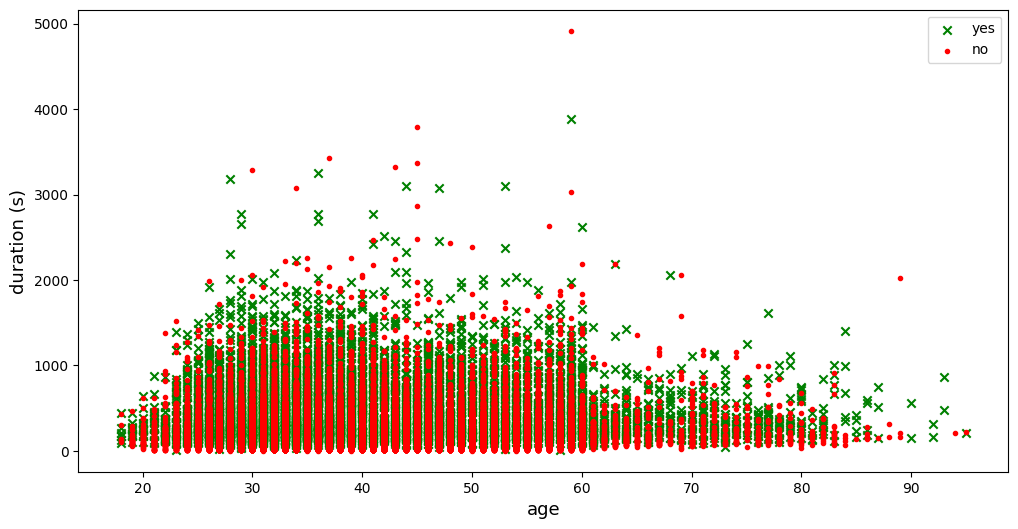

In [22]:
plt.figure(figsize=(12, 6))
plt.scatter(df['age'][df['y']=='yes'], df['duration'][df['y']=='yes'], c='g', marker='x', label='yes')
plt.scatter(df['age'][df['y']=='no'],  df['duration'][df['y']=='no'],  c='r', marker='.', label='no')
plt.xlabel('age', fontsize=13)
plt.ylabel('duration (s)', fontsize=13)
plt.legend()
plt.show()

## 3. División del conjunto de datos

_Se aplica la división estratificada 60/20/20. El parámetro `stratify='y'` es clave para preservar la proporción de clases en cada subconjunto dado el desbalance existente._

In [23]:
train_set, val_set, test_set = train_val_test_split(df, stratify='y')

_Se separan características y etiquetas en los tres subconjuntos. A partir de aquí se trabaja con `X_train`/`y_train`, `X_val`/`y_val` y `X_test`/`y_test` de forma independiente._

In [24]:
X_train, y_train = remove_labels(train_set, 'y')
X_val,   y_val   = remove_labels(val_set,   'y')
X_test,  y_test  = remove_labels(test_set,  'y')

## 4. Preparación del conjunto de datos

_Se identifican por separado las columnas categóricas (tipo `object`) y numéricas. Este paso es necesario porque cada tipo requiere un tratamiento diferente: **One-Hot Encoding** para categóricas y **escalado** para numéricas. **Resultado esperado:** dos listas de nombres de columnas._

In [25]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()
print('Categóricas:', cat_cols)
print('Numéricas  :', num_cols)

Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numéricas  : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


/tmp/ipykernel_25870/1503212914.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns.tolist()


_**One-Hot Encoding** — convierte cada columna categórica en tantas columnas binarias (0/1) como valores únicos tenga. Por ejemplo, `job='admin.'` se convierte en `job_admin.=1` y el resto a 0. Se aplica `fit_transform` en entrenamiento (aprende las categorías) y `transform` en validación y prueba. El parámetro `handle_unknown='ignore'` evita errores si validación contiene categorías no vistas en entrenamiento. **Resultado:** las 9 columnas categóricas se expanden en varias decenas de columnas binarias._

In [26]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_cat = pd.DataFrame(
    encoder.fit_transform(X_train[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index)

X_val_cat = pd.DataFrame(
    encoder.transform(X_val[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_val.index)

X_test_cat = pd.DataFrame(
    encoder.transform(X_test[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index)

_Se concatenan las columnas numéricas originales con las columnas binarias generadas por One-Hot Encoding. **Resultado esperado:** DataFrames completamente numéricos listos para el modelo._

In [27]:
X_train_prep = pd.concat([X_train[num_cols], X_train_cat], axis=1)
X_val_prep   = pd.concat([X_val[num_cols],   X_val_cat],   axis=1)
X_test_prep  = pd.concat([X_test[num_cols],  X_test_cat],  axis=1)

_Se aplica `SimpleImputer` con la mediana para cubrir posibles valores nulos. Se hace `fit` solo en entrenamiento y `transform` en los demás. **Resultado esperado:** DataFrames sin ningún valor nulo._

In [28]:
imputer = SimpleImputer(strategy='median')
X_train_prep = pd.DataFrame(imputer.fit_transform(X_train_prep), columns=X_train_prep.columns, index=X_train_prep.index)
X_val_prep   = pd.DataFrame(imputer.transform(X_val_prep),       columns=X_val_prep.columns,   index=X_val_prep.index)
X_test_prep  = pd.DataFrame(imputer.transform(X_test_prep),      columns=X_test_prep.columns,  index=X_test_prep.index)

_**Resultado esperado:** tabla con las columnas numéricas originales seguidas de las columnas binarias del One-Hot Encoding. Las columnas categóricas ya no aparecen como texto._

In [29]:
X_train_prep.head(10)

,age,balance,day,duration,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
217,53.0,13.0,5.0,410.0,3.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
34160,54.0,0.0,30.0,766.0,3.0,84.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
34607,30.0,280.0,5.0,92.0,3.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
447,50.0,-84.0,6.0,101.0,1.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
23636,60.0,1690.0,28.0,64.0,11.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
21132,30.0,1384.0,14.0,60.0,2.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
22210,32.0,0.0,21.0,660.0,2.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10603,49.0,3250.0,16.0,32.0,3.0,-1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
36302,50.0,199.0,11.0,228.0,2.0,363.0,2.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
31676,38.0,2012.0,7.0,355.0,3.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


_**Resultado esperado:** serie vacía, confirmando que la preparación eliminó cualquier valor nulo y el dataset está listo para el entrenamiento._

In [30]:
is_null = X_train_prep.isna().any()
is_null[is_null]

Series([], dtype: bool)

## 5. Regresión Logística: sin escalado

### 5.1 Conjunto de datos reducido

_Para visualizar la frontera de decisión en 2D se reduce el dataset a solo `age` y `duration`. En alta dimensión la frontera es un hiperplano no representable gráficamente._

In [31]:
X_train_reduced = X_train_prep[['age', 'duration']].copy()
X_val_reduced   = X_val_prep[['age', 'duration']].copy()

_Se entrena la Regresión Logística sobre el conjunto reducido (2 variables, sin escalar). `max_iter=1000` evita avisos de convergencia._

In [32]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_reduced, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

_**Gráfico de la frontera de decisión.** Los **puntos verdes (×)** son `yes` y los **rojos (·)** son `no`. La **línea negra** marca donde la probabilidad predicha es 0,5. Con solo dos variables la separación es muy limitada y la mayoría de `yes` queda mezclada con `no`._

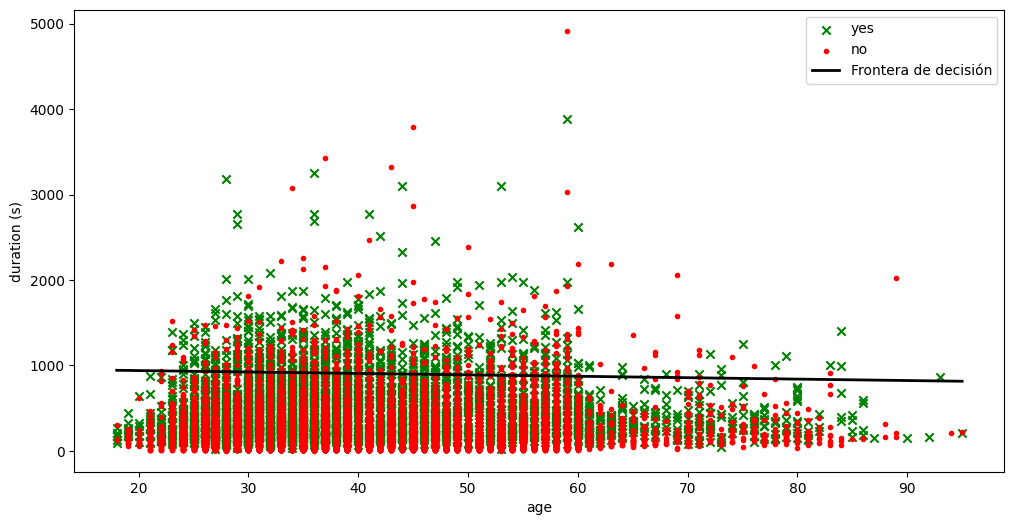

In [33]:
plt.figure(figsize=(12, 6))
plt.scatter(X_train_reduced['age'][y_train=='yes'], X_train_reduced['duration'][y_train=='yes'], c='g', marker='x', label='yes')
plt.scatter(X_train_reduced['age'][y_train=='no'],  X_train_reduced['duration'][y_train=='no'],  c='r', marker='.', label='no')
plot_lr_decision_boundary(log_reg, X_train_reduced['age'].min(), X_train_reduced['age'].max())
plt.xlabel('age'); plt.ylabel('duration (s)'); plt.legend(); plt.show()

_**Resultado esperado:** F1 Score bajo (≈ 0.30–0.45) porque el modelo dispone de muy poca información con solo dos variables._

In [34]:
y_pred = log_reg.predict(X_val_reduced)
print('F1 Score:', f1_score(y_pred, y_val, pos_label='yes'))

F1 Score: 0.24532535527299926


### 5.2 Conjunto de datos completo sin escalado

_Se entrena con las 16 variables preprocesadas (numéricas + One-Hot). Sin escalar, variables de rangos muy distintos pueden dificultar la convergencia del optimizador._

In [35]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_prep, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

_**Resultado esperado:** F1 Score claramente superior al del conjunto reducido._

In [36]:
y_pred = log_reg.predict(X_val_prep)
print('F1 Score:', f1_score(y_pred, y_val, pos_label='yes'))

F1 Score: 0.4392350400987045


## 6. Regresión Logística: con escalado

### 6.1 Solver lbfgs con regularización L2 (por defecto)

_Se construye un **Pipeline** que encadena `RobustScaler` y `LogisticRegression`. `RobustScaler` usa la mediana y el IQR, robusto ante valores extremos. Primero se entrena sobre el conjunto reducido para visualizar la frontera escalada._

In [37]:
log_reg_sc = Pipeline([
    ('scaler', RobustScaler()),
    ('log_reg', LogisticRegression(random_state=42, max_iter=1000))
])
log_reg_sc.fit(X_train_reduced, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('log_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['age','duration']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"


_**Gráfico de la frontera de decisión con escalado.** La recta puede desplazarse respecto a la versión sin escalar porque el escalado cambia las magnitudes relativas de las variables._

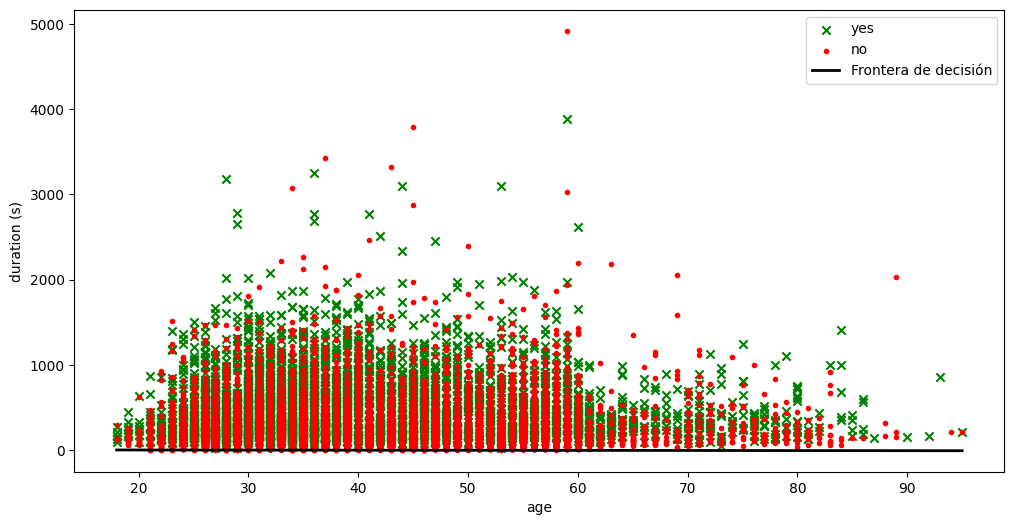

In [38]:
plt.figure(figsize=(12, 6))
plt.scatter(X_train_reduced['age'][y_train=='yes'], X_train_reduced['duration'][y_train=='yes'], c='g', marker='x', label='yes')
plt.scatter(X_train_reduced['age'][y_train=='no'],  X_train_reduced['duration'][y_train=='no'],  c='r', marker='.', label='no')
plot_lr_decision_boundary(log_reg_sc.named_steps['log_reg'], X_train_reduced['age'].min(), X_train_reduced['age'].max())
plt.xlabel('age'); plt.ylabel('duration (s)'); plt.legend(); plt.show()

_**Resultado esperado:** F1 Score similar al sin escalar sobre el conjunto reducido. El escalado tiene más impacto con el dataset completo._

In [39]:
y_pred_red_sc = log_reg_sc.predict(X_val_reduced)
print('F1 Score (reducido):', f1_score(y_pred_red_sc, y_val, pos_label='yes'))

F1 Score (reducido): 0.24532535527299926


_Se reentrena el pipeline sobre el **dataset completo**. Esta es la configuración base de Regresión Logística con mejor rendimiento esperado._

In [40]:
log_reg_sc = Pipeline([
    ('scaler', RobustScaler()),
    ('log_reg', LogisticRegression(random_state=42, max_iter=1000))
])
log_reg_sc.fit(X_train_prep, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('log_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](51,)","['age','balance','day',...,'poutcome_other','poutcome_success', 'poutcome_unknown']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,51
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"


_**Resultado esperado:** F1 Score igual o superior al obtenido sin escalado. El escalado mejora la convergencia cuando las variables tienen rangos muy distintos._

In [41]:
y_pred_lr_base = log_reg_sc.predict(X_val_prep)
print('F1 Score:', f1_score(y_pred_lr_base, y_val, pos_label='yes'))

F1 Score: 0.45521472392638035


### 6.2 Solver liblinear con regularización L1

_La **regularización L1** fuerza algunos coeficientes a ser exactamente cero, actuando como selección automática de características. El solver `liblinear` es necesario para usar L1._

In [42]:
log_reg_l1 = Pipeline([
    ('scaler', RobustScaler()),
    ('log_reg', LogisticRegression(penalty='l1', solver='liblinear', C=1, random_state=42, max_iter=1000))
])
log_reg_l1.fit(X_train_prep, y_train)

/home/hisoka/Escritorio/topicoD/topicos-d/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('log_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](51,)","['age','balance','day',...,'poutcome_other','poutcome_success', 'poutcome_unknown']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,51
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"


_**Resultado esperado:** F1 Score comparable al de L2. Si hay variables poco informativas, L1 puede mejorar el resultado al anularlas._

In [43]:
y_pred_l1 = log_reg_l1.predict(X_val_prep)
print('F1 Score:', f1_score(y_pred_l1, y_val, pos_label='yes'))

F1 Score: 0.4567219152854512


### 6.3 Exploración del hiperparámetro C

_Se prueban distintos valores de `C` para encontrar el nivel de regularización óptimo. `C` pequeño → más regularización → modelo más simple. `C` grande → menos regularización → posible sobreajuste. **Gráfico esperado:** curva que sube y luego se estabiliza o baja levemente._

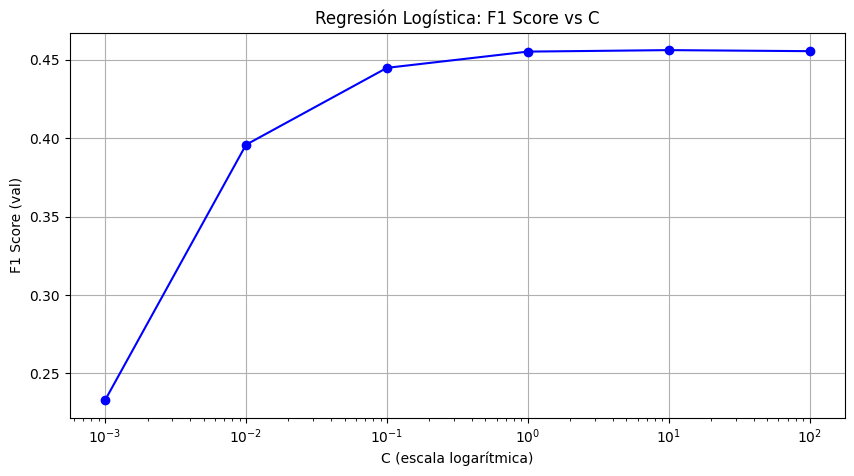

Mejor C: 10  —  F1 Score: 0.4562


In [44]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
f1_C = []

for C in C_values:
    clf = Pipeline([('scaler', RobustScaler()),
                    ('log_reg', LogisticRegression(C=C, random_state=42, max_iter=1000))])
    clf.fit(X_train_prep, y_train)
    f1_C.append(f1_score(clf.predict(X_val_prep), y_val, pos_label='yes'))

plt.figure(figsize=(10, 5))
plt.semilogx(C_values, f1_C, 'bo-')
plt.xlabel('C (escala logarítmica)'); plt.ylabel('F1 Score (val)')
plt.title('Regresión Logística: F1 Score vs C'); plt.grid(True); plt.show()

best_C = C_values[f1_C.index(max(f1_C))]
print(f'Mejor C: {best_C}  —  F1 Score: {max(f1_C):.4f}')

_Se entrena el modelo final de Regresión Logística con el mejor valor de `C` encontrado._

In [45]:
log_reg_best = Pipeline([
    ('scaler', RobustScaler()),
    ('log_reg', LogisticRegression(C=best_C, random_state=42, max_iter=1000))
])
log_reg_best.fit(X_train_prep, y_train)
y_pred_lr = log_reg_best.predict(X_val_prep)
print('F1 Score (mejor LR):', f1_score(y_pred_lr, y_val, pos_label='yes'))

F1 Score (mejor LR): 0.45616186388718577


## 7. Random Forest

### 7.1 Modelo base

_Se entrena un Random Forest con 100 árboles como punto de partida. A diferencia de la Regresión Logística, **no requiere escalado** porque los árboles de decisión no son sensibles a los rangos de las variables._

In [46]:
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_rf.fit(X_train_prep, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

_**Resultado esperado:** F1 Score superior al de la Regresión Logística base, ya que Random Forest es un modelo de ensamble con mayor capacidad de capturar relaciones no lineales._

In [47]:
y_pred_rf_base = clf_rf.predict(X_val_prep)
print('F1 Score:', f1_score(y_pred_rf_base, y_val, pos_label='yes'))

F1 Score: 0.493708807669263


### 7.2 Exploración de n_estimators

_Se prueba el efecto del número de árboles sobre el F1 Score. Más árboles reducen la varianza (menos sobreajuste), pero a partir de cierto punto el beneficio se estabiliza y el tiempo de entrenamiento sigue aumentando. **Gráfico esperado:** curva ascendente que se aplana._

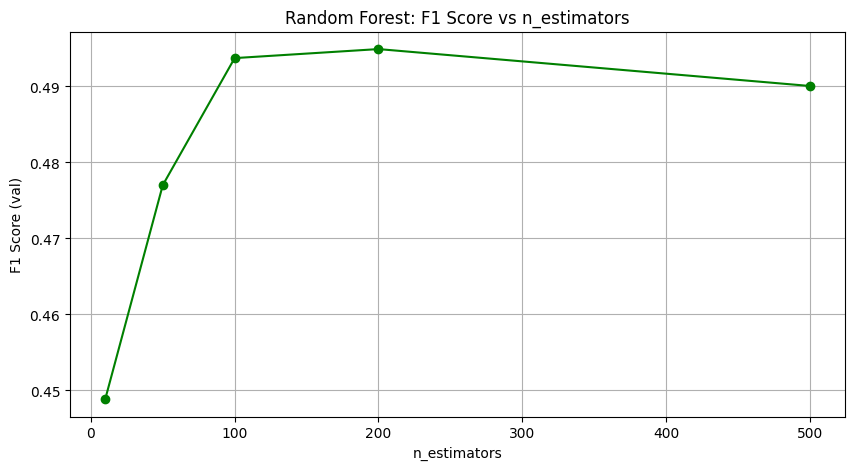

Mejor n_estimators: 200  —  F1 Score: 0.4949


In [48]:
n_values = [10, 50, 100, 200, 500]
f1_n = []

for n in n_values:
    clf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    clf.fit(X_train_prep, y_train)
    f1_n.append(f1_score(clf.predict(X_val_prep), y_val, pos_label='yes'))

plt.figure(figsize=(10, 5))
plt.plot(n_values, f1_n, 'go-')
plt.xlabel('n_estimators'); plt.ylabel('F1 Score (val)')
plt.title('Random Forest: F1 Score vs n_estimators'); plt.grid(True); plt.show()

best_n = n_values[f1_n.index(max(f1_n))]
print(f'Mejor n_estimators: {best_n}  —  F1 Score: {max(f1_n):.4f}')

### 7.3 Exploración de max_depth

_`max_depth` controla la profundidad máxima de cada árbol. Sin límite (`None`) cada árbol puede memorizar los datos (sobreajuste); con límite bajo el modelo es demasiado simple (infraajuste). **Gráfico esperado:** curva con un máximo en algún valor intermedio o con tendencia ascendente hasta `None`._

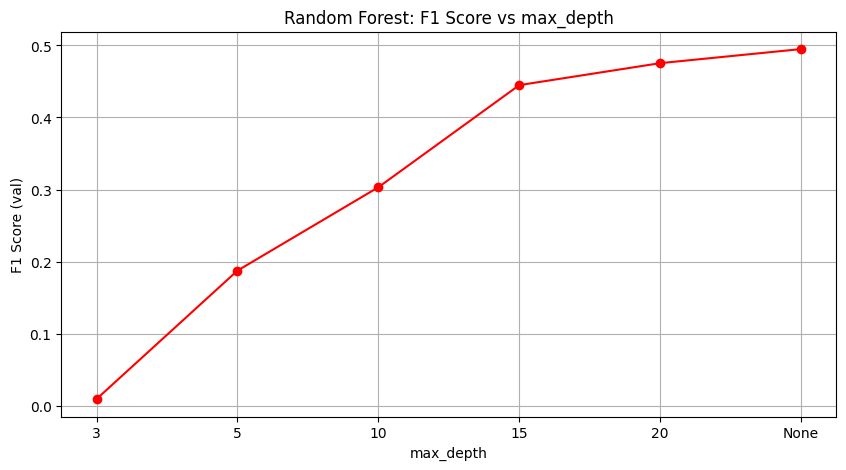

Mejor max_depth: None  —  F1 Score: 0.4949


In [49]:
depth_values = [3, 5, 10, 15, 20, None]
depth_labels = ['3', '5', '10', '15', '20', 'None']
f1_d = []

for d in depth_values:
    clf = RandomForestClassifier(n_estimators=best_n, max_depth=d, random_state=42, n_jobs=-1)
    clf.fit(X_train_prep, y_train)
    f1_d.append(f1_score(clf.predict(X_val_prep), y_val, pos_label='yes'))

plt.figure(figsize=(10, 5))
plt.plot(depth_labels, f1_d, 'ro-')
plt.xlabel('max_depth'); plt.ylabel('F1 Score (val)')
plt.title('Random Forest: F1 Score vs max_depth'); plt.grid(True); plt.show()

best_depth = depth_values[f1_d.index(max(f1_d))]
print(f'Mejor max_depth: {best_depth}  —  F1 Score: {max(f1_d):.4f}')

_Se entrena el modelo final de Random Forest con los mejores hiperparámetros encontrados._

In [50]:
clf_rf_best = RandomForestClassifier(n_estimators=best_n, max_depth=best_depth, random_state=42, n_jobs=-1)
clf_rf_best.fit(X_train_prep, y_train)
y_pred_rf = clf_rf_best.predict(X_val_prep)
print(f'F1 Score (mejor RF — n={best_n}, depth={best_depth}):', f1_score(y_pred_rf, y_val, pos_label='yes'))

F1 Score (mejor RF — n=200, depth=None): 0.4948948948948949


### 7.4 Importancia de características

_Random Forest calcula la **importancia de cada variable** como la reducción media de impureza que aporta en todos los árboles. **Gráfico esperado:** barras ordenadas de mayor a menor importancia. Se espera que `duration` sea la variable más importante, seguida de factores económicos como `balance` y `age`._

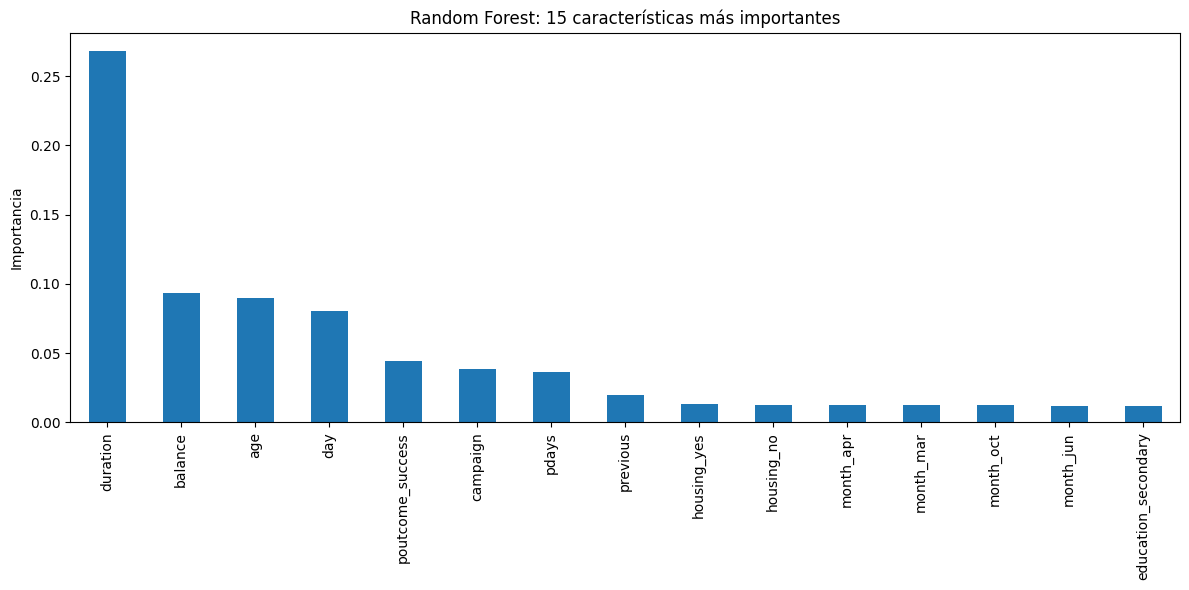

duration            0.267858
balance             0.093364
age                 0.089600
day                 0.080287
poutcome_success    0.044524
campaign            0.038617
pdays               0.036040
previous            0.019546
housing_yes         0.012908
housing_no          0.012770
dtype: float64


In [51]:
feature_importances = pd.Series(
    clf_rf_best.feature_importances_, index=X_train_prep.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feature_importances.head(15).plot(kind='bar')
plt.title('Random Forest: 15 características más importantes')
plt.ylabel('Importancia'); plt.tight_layout(); plt.show()

print(feature_importances.head(10))

## 8. Comparación de modelos

_Se muestran los reportes de clasificación completos de ambos modelos. Incluyen **precisión**, **recall** y **F1** para cada clase. Hay que prestar especial atención a la clase `yes` (la minoritaria), ya que es la que tiene relevancia práctica — identificar correctamente qué clientes aceptarán la campaña. El **desbalance de clases** (≈88 % `no` / ≈12 % `yes`) penaliza especialmente el recall de la clase `yes`, ya que el modelo tiende a predecir `no` con más frecuencia._

In [52]:
print('=== Regresión Logística ===')
print(classification_report(y_val, y_pred_lr, target_names=['no', 'yes']))

print('=== Random Forest ===')
print(classification_report(y_val, y_pred_rf, target_names=['no', 'yes']))

=== Regresión Logística ===
              precision    recall  f1-score   support

          no       0.92      0.97      0.95      7984
         yes       0.65      0.35      0.46      1058

    accuracy                           0.90      9042
   macro avg       0.78      0.66      0.70      9042
weighted avg       0.89      0.90      0.89      9042

=== Random Forest ===
              precision    recall  f1-score   support

          no       0.92      0.98      0.95      7984
         yes       0.68      0.39      0.49      1058

    accuracy                           0.91      9042
   macro avg       0.80      0.68      0.72      9042
weighted avg       0.89      0.91      0.90      9042



_Comparación directa del **F1 Score** de ambos modelos usando la función `evaluate_result`. El modelo con mayor F1 en la clase `yes` es el más conveniente para este problema._

In [53]:
evaluate_result(y_pred_lr, y_val, y_pred_rf, y_val, f1_score)

f1_score Regresión Logística: 0.45616186388718577
f1_score Random Forest      : 0.4948948948948949
